# CESM2 NAO

In [1]:
import os
import sys
import yaml
import copy

import numpy as np
import pandas as pd
import xarray as xr

/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


In [2]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from eofs.xarray import Eof
import xeofs as xe

In [13]:
import pickle
print("xeofs =", xe.__version__)
print("xarray =", xr.__version__)

xeofs = 3.0.4
xarray = 2026.2.0


In [6]:
base_dir = '/glade/derecho/scratch/ksha/EPRI_data/ERA5_grid/'

In [7]:
# list_nao = []

# list_ds = []
# for year in range(1958, 2026):
#     fn_ERA5 = base_dir + f'/ERA5_{year}.zarr'
#     ds_ERA5 = xr.open_zarr(fn_ERA5)
#     ds = ds_ERA5[['mean_sea_level_pressure']].rename({'mean_sea_level_pressure': 'PSL'})
#     list_ds.append(ds)

# ds_all = xr.concat(list_ds, dim='time').sortby('time')

list_nao = []

list_ds = []
for year in range(1958, 2026):
    fn_ERA5 = base_dir + f'/ERA5_{year}.zarr'
    ds_ERA5 = xr.open_zarr(fn_ERA5)
    ds = ds_ERA5[['geopotential']].rename({'geopotential': 'Z500'})
    list_ds.append(ds)

ds_all = xr.concat(list_ds, dim='time').sortby('time')

In [8]:
# SLP in hPa and convert daily -> monthly
# slp = ds_all['PSL'] / 100.0

slp = ds_all['Z500']
slp = slp.resample(time="MS").mean()

# convert lon to [-180, 180)
slp = slp.assign_coords(
    lon=((slp.lon + 180) % 360) - 180
).sortby("lon")

# robust lat slicing
if slp.lat[0] < slp.lat[-1]:
    slp_na = slp.sel(lat=slice(0, 90)) # , lon=slice(-90, 40)
else:
    slp_na = slp.sel(lat=slice(90, 0)) # , lon=slice(-90, 40)

# monthly anomaly
slp_mon_clim = slp_na.groupby("time.month").mean("time")
anom = slp_na.groupby("time.month") - slp_mon_clim
anom = anom.transpose("time", "lat", "lon")

In [9]:
# # weights
# w_lat = np.sqrt(np.cos(np.deg2rad(anom["lat"])))
# weights_2d = xr.DataArray(
#     np.broadcast_to(w_lat.values[:, None], (anom.sizes["lat"], anom.sizes["lon"])),
#     coords={"lat": anom["lat"], "lon": anom["lon"]},
#     dims=("lat", "lon"),
# )

# # EOF
# solver = Eof(anom, weights=weights_2d)
# eof1 = solver.eofs(neofs=1)[0]
# pc1 = solver.pcs(npcs=1, pcscaling=1)[:, 0]

In [10]:
n_modes_eof = 20
n_modes_rotate = 10

eof_model = xe.single.EOF(
    n_modes=n_modes_eof,
    standardize=False,
    use_coslat=True,
)
eof_model.fit(anom, dim="time")

rotator = xe.single.EOFRotator(n_modes=n_modes_rotate)
rotator.fit(eof_model)

# optional training outputs
eof = eof_model.components()
pc = eof_model.scores(normalized=False)

reof = rotator.components()
rpc = rotator.scores(normalized=False)

eof1 = eof.isel(mode=0)
pc1_eof = pc.isel(mode=0)

reof1 = reof.isel(mode=0)
pc1 = pc1_reof = rpc.isel(mode=0)


/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'dim2', 'dim1'} to avoid an error in the future.
  X_transformed = X_transformed.drop_vars(dim)


In [14]:
# Save
with open("eof_model.pkl", "wb") as f:
    pickle.dump(eof_model, f)

In [21]:
# rotator.save("/glade/derecho/scratch/ksha/EPRI_data/METRICS/reof_model.zarr", overwrite=True)

with open("reof_model.pkl", "wb") as f:
    pickle.dump(rotator, f)

In [16]:
# sign convention using simple monthly box NAO
if slp.lat[0] < slp.lat[-1]:
    south = slp.sel(lat=slice(35, 40), lon=slice(-35, -20)).mean(("lat", "lon"))
    north = slp.sel(lat=slice(60, 70), lon=slice(-30, -10)).mean(("lat", "lon"))
else:
    south = slp.sel(lat=slice(40, 35), lon=slice(-35, -20)).mean(("lat", "lon"))
    north = slp.sel(lat=slice(70, 60), lon=slice(-30, -10)).mean(("lat", "lon"))

nao_box = south - north
nao_box = nao_box.groupby("time.month") - nao_box.groupby("time.month").mean("time")

corr = float(xr.corr(pc1, nao_box))
print(corr)

if corr < 0:
    pc1 = -pc1

# pc1 is already monthly
pc1 = nao_monthly = (pc1 - pc1.mean("time")) / pc1.std("time")
nao_monthly.name = "nao_monthly_eof"

# annual
nao_ann = nao_monthly.groupby("time.year").mean("time")
nao_ann.name = "nao_ann_eof"

# DJF
years = np.asarray(np.unique(nao_monthly["time.year"].values))
first_year = int(years.min())

pieces = []
jf_first = nao_monthly.where(
    (nao_monthly["time.year"] == first_year) &
    (nao_monthly["time.month"].isin([1, 2])),
    drop=True
)

if jf_first.sizes.get("time", 0) == 2:
    jf_first_mean = jf_first.mean("time")
    jf_first_mean = jf_first_mean.expand_dims(year=[first_year])
    pieces.append(jf_first_mean)
    
djf_raw = (
    nao_monthly.where(nao_monthly["time.month"].isin([12, 1, 2]), drop=True)
               .resample(time="QS-DEC")
)

djf = djf_raw.mean()
djf_count = djf_raw.count()

djf = djf.where(djf_count == 3, drop=True)
djf = djf.where(djf["time.month"] == 12, drop=True)
djf = djf.assign_coords(year=djf["time.year"] + 1)
djf = djf.swap_dims({"time": "year"}).drop_vars("time")
djf = djf.dropna("year")

# avoid duplicate first year if it somehow exists
djf = djf.where(djf["year"] != first_year, drop=True)
pieces.append(djf)

nao_djf = xr.concat(pieces, dim="year").sortby("year")
nao_djf.name = "nao_djf_eof"


# other seasons
nao_mam = nao_monthly.where(nao_monthly["time.month"].isin([3, 4, 5]), drop=True).groupby("time.year").mean("time")
nao_jja = nao_monthly.where(nao_monthly["time.month"].isin([6, 7, 8]), drop=True).groupby("time.year").mean("time")
nao_son = nao_monthly.where(nao_monthly["time.month"].isin([9, 10, 11]), drop=True).groupby("time.year").mean("time")

nao_mam.name = "nao_mam_eof"
nao_jja.name = "nao_jja_eof"
nao_son.name = "nao_son_eof"

ds_nao_yearly = xr.Dataset({
    "nao_ann_eof": nao_ann,
    "nao_djf_eof": nao_djf,
    "nao_mam_eof": nao_mam,
    "nao_jja_eof": nao_jja,
    "nao_son_eof": nao_son,
})

ds_nao_yearly = ds_nao_yearly.rename({'year': 'init_year'})
ds_nao_yearly = ds_nao_yearly.assign_coords({'init_year': np.arange(1958, 2026)})

-0.711412038765688


In [17]:
save_name = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_ERA5_REOF.zarr'
ds_nao_yearly = ds_nao_yearly.chunk({'init_year': 62,})
ds_nao_yearly.to_zarr(save_name, mode='w')

In [18]:
ds_monthly = nao_monthly.to_dataset(name="NAO monthly")
save_name = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_mon_ERA5_REOF.zarr'
ds_monthly = ds_monthly.chunk({'time': 744,})
ds_monthly.to_zarr(save_name, mode='w')

In [23]:
pc1[-72:-60].values

array([ 1.24788829,  1.20535185,  0.48059262, -0.64440854,  0.41192942,
       -0.24493272,  0.07188781,  0.0516579 ,  1.30690996,  0.14088006,
        1.75052888, -0.09695772])

In [19]:
pc1[-12:].values

array([-1.62044334e+00,  5.03552278e-01,  4.48448521e-01,  1.26811968e-03,
        2.30080537e-01,  9.50688766e-01,  6.19865187e-01,  2.17644086e-01,
       -4.01830687e-01, -7.84476013e-01, -1.24424872e+00,  4.71137801e-01])

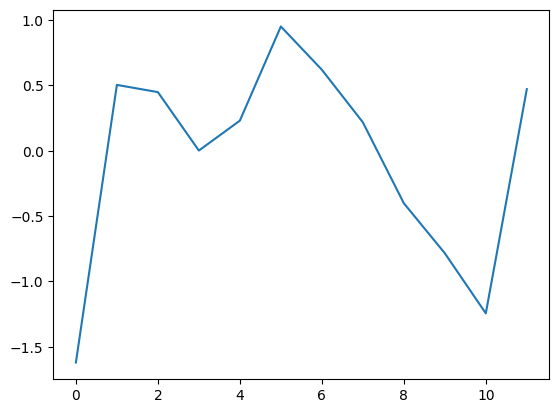

In [20]:
plt.plot(pc1.values[-12:])